# Your First Simulation

Welcome to brainmass. In this first tutorial you will run a single neural-mass model from
start to finish using only the **high-level API** — no hand-written integration loops. By
the end you will be able to:

1. **construct** a model and initialise its state,
2. **run** it for a chosen duration with the {class}`~brainmass.Simulator`,
3. **plot** the result with {mod}`brainmass.viz`, and
4. **change one parameter** and re-run to *see* the effect.

We will use the {class}`~brainmass.FitzHughNagumoStep` model — a classic two-variable model
of an *excitable* unit. It sits quietly at rest until a stimulus pushes it past a threshold,
at which point it fires a single large excursion (a "spike") before relaxing back. That makes
the effect of a parameter change easy to see.

:::{note}
Every code cell on this page is executed when the notebook is authored, so the outputs you
see are real. For the 10-minute tour of the *whole* library — networks, noise, and
gradient-based fitting — see {doc}`/getting_started/quickstart`.
:::

## Setup

We import brainmass and a few companions. {mod}`brainunit` (`u`) gives us **unit-aware**
quantities: the time step `dt` and the run `duration` are physical times like `0.1 * u.ms`,
not bare numbers. We set a global `dt` once through the environment; the `Simulator` also
takes it explicitly below.

In [1]:
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import matplotlib.pyplot as plt

brainstate.environ.set(dt=0.1 * u.ms)
brainmass.__version__

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


'0.0.6'

## 1. Construct a model

A brainmass model is a `*Step` object — one update step of a neural-mass equation, sized for
`in_size` regions. Here we build a **single** FitzHugh–Nagumo unit (`in_size=1`). It carries
two state variables: a fast activator `V` (membrane-potential–like) and a slow recovery
variable `w`.

In [2]:
node = brainmass.FitzHughNagumoStep(in_size=1)
node

FitzHughNagumoStep(
  in_size=(1,),
  out_size=(1,),
  alpha=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(3., dtype=float32)
  ),
  beta=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(4., dtype=float32)
  ),
  gamma=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(-1.5, dtype=float32)
  ),
  delta=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0., dtype=float32)
  ),
  epsilon=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.5, dtype=float32)
  ),
  tau=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Quantity(20., "ms")
  ),
  init_V=Uniform(low=0, high=0.05),
  init_w=Uniform(low=0, high=0.05),
  method=exp_euler
)

## 2. Run it with the `Simulator`

The {class}`~brainmass.Simulator` owns the whole run loop. A single `.run(...)` call:

- sets `dt` and **initialises** the model's state (`init_all_states`),
- steps the model forward, and
- returns the recorded trajectories as a plain dict.

How many steps is that? The number of integration steps is `duration / dt`. With
`duration = 200 * u.ms` and `dt = 0.1 * u.ms` that is **2000 steps**.

We give the unit a brief external **stimulus**: a current pulse to `V` between 20 ms and
22 ms, via the `inputs=` callback (it receives the step index `i` and time `t` and returns
the drive for that step). We record both state variables by name with `monitors=['V', 'w']`.

In [3]:
def stimulus(i, t):
    """A brief supra-threshold current pulse to V between 20 and 22 ms."""
    pulse = jnp.where((t > 20.0 * u.ms) & (t < 22.0 * u.ms), 1.5, 0.0)
    return (pulse,)

sim = brainmass.Simulator(node, dt=0.1 * u.ms)
res = sim.run(200.0 * u.ms, inputs=stimulus, monitors=["V", "w"])

print("recorded keys:", list(res))
print("V trajectory shape (steps, regions):", res["V"].shape)
print("time axis runs from", res["ts"][0], "to", res["ts"][-1])

recorded keys: ['V', 'w', 'ts']
V trajectory shape (steps, regions): (2000, 1)
time axis runs from 0.1 ms to 200. ms


## 3. Plot the result

{func}`brainmass.viz.plot_timeseries` takes the trajectory and the time axis directly. The
single sub-threshold rest is interrupted by one clean spike right after the 20 ms pulse — the
hallmark of an excitable unit.

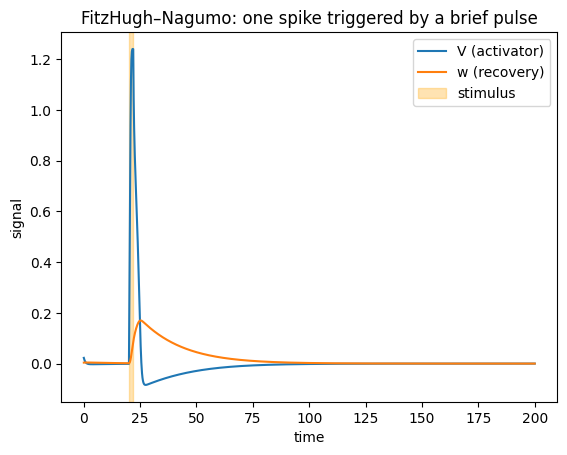

In [4]:
ax = brainmass.viz.plot_timeseries(
    res["V"], ts=res["ts"], labels=["V (activator)"]
)
brainmass.viz.plot_timeseries(res["w"], ts=res["ts"], labels=["w (recovery)"], ax=ax)
ax.axvspan(20, 22, color="orange", alpha=0.3, label="stimulus")
ax.legend()
ax.set_title("FitzHugh–Nagumo: one spike triggered by a brief pulse");

## A note on transients

Models often start away from their natural operating point and need a few milliseconds to
settle. That initial **transient** is usually not interesting, so the `Simulator` can discard
it for you: pass `transient=<duration>` and the first stretch is dropped from the returned
arrays (the run itself is unchanged — only the *output* is trimmed).

In [5]:
res_full = sim.run(200.0 * u.ms, inputs=stimulus, monitors=["V"])
res_trim = sim.run(200.0 * u.ms, inputs=stimulus, monitors=["V"], transient=50.0 * u.ms)

print("without transient discard:", res_full["V"].shape[0], "recorded steps")
print("with 50 ms discarded:    ", res_trim["V"].shape[0], "recorded steps")
print("first recorded time now starts at", res_trim["ts"][0])

without transient discard: 2000 recorded steps
with 50 ms discarded:     1500 recorded steps
first recorded time now starts at 50.1 ms


## 4. Change one parameter and see the effect

The point of a *model* is that its parameters control its behaviour. The recovery time
constant `tau` sets how quickly the slow variable `w` chases the activator. Make `tau` larger
and recovery is sluggish, so the spike is broader; make it smaller and the unit snaps back
faster.

We build the *same* model three times with different `tau`, run each, and overlay the
activator traces. Constructing-running-plotting is so concise that a parameter sweep is just
a loop over model builds.

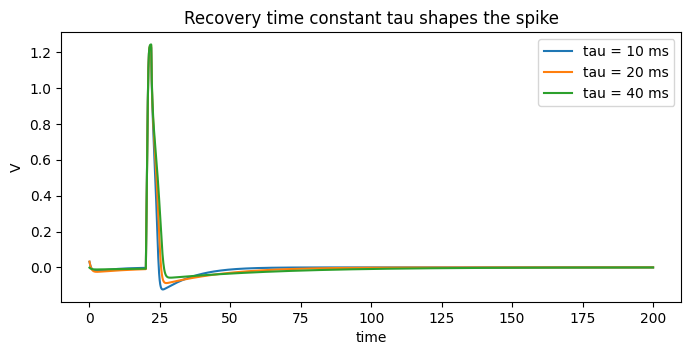

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))

for tau in [10.0, 20.0, 40.0]:
    model = brainmass.FitzHughNagumoStep(in_size=1, tau=tau * u.ms)
    r = brainmass.Simulator(model, dt=0.1 * u.ms).run(
        200.0 * u.ms, inputs=stimulus, monitors=["V"]
    )
    brainmass.viz.plot_timeseries(
        r["V"], ts=r["ts"], labels=[f"tau = {tau:.0f} ms"], ax=ax
    )

ax.set_title("Recovery time constant tau shapes the spike")
ax.set_ylabel("V");

## What you learned

- A model is a `*Step` object sized for `in_size` regions.
- `Simulator(model, dt=...).run(duration, monitors=...)` initialises, steps, and collects
  trajectories — `duration / dt` gives the number of steps.
- `monitors=[...]` records named state variables; `inputs=` injects an external drive;
  `transient=` trims the warm-up from the output.
- {mod}`brainmass.viz` turns trajectories into plots in one line.
- Changing a parameter and re-running is the basic loop of model exploration.

## Next steps

- {doc}`/tutorials/02_models_and_dynamics` — tour the model families and watch a parameter
  move a system across a **bifurcation**.
- {doc}`/tutorials/03_noise` — add stochastic fluctuations.
- {doc}`/gallery/index` — a runnable demo for every model in the library.